A perceptron is the fundamental building block of neural networks, acting as a simplified, mathematical model of a biological neuron designed for binary classification. Introduced by Frank Rosenblatt in 1957, it processes input data by applying weights, summing them, and using an activation function to determine if the output is 0 or 1, effectively separating data linearly.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

w1 = 0.5
w2 = 0.5
b = -0.5
eta = 1.0

data = [
    [1, 0.8, 0.6, 1],
    [2, 0.3, 0.2, 0],
    [3, 0.6, 0.8, 1],
    [4, 0.2, 0.4, 0]
]

def activation(z):
    return 1 if z >= 0 else 0

results = []


for sample, x1, x2, d in data:
    
    z = w1 * x1 + w2 * x2 + b
    
    y = activation(z)
    
    error = d - y
    
    update_required = "Yes" if error != 0 else "No"
    
    results.append([
        sample,
        x1,
        x2,
        round(z, 2),
        y,
        d,
        error,
        update_required
    ])
    
    w1 = w1 + eta * error * x1
    w2 = w2 + eta * error * x2
    b = b + eta * error

columns = ["Sample", "x_1", "x_2", "z", "y", "d", "d-y", "Update Required?"]
df = pd.DataFrame(results, columns=columns)

print("\n[TABLE 2: Student Work Area - Epoch 1]\n")
print(df)

print("\nFinal Weights After Epoch 1:")
print("w1 =", w1)
print("w2 =", w2)
print("b  =", b)



[TABLE 2: Student Work Area - Epoch 1]

   Sample  x_1  x_2     z  y  d  d-y Update Required?
0       1  0.8  0.6  0.20  1  1    0               No
1       2  0.3  0.2 -0.25  0  0    0               No
2       3  0.6  0.8  0.20  1  1    0               No
3       4  0.2  0.4 -0.20  0  0    0               No

Final Weights After Epoch 1:
w1 = 0.5
w2 = 0.5
b  = -0.5


In [6]:
X_train = np.array([
        [0.8, 0.6],
        [0.3, 0.2],
        [0.6, 0.8],
        [0.2, 0.4]
    ])    
y_train = np.array([1, 0, 1, 0])
   
print("Feature matrix shape:", X_train.shape)
print("Target vector shape:", y_train.shape)


Feature matrix shape: (4, 2)
Target vector shape: (4,)


In [7]:
perceptron = Perceptron(
        eta0=1.0,           # learning rate
        max_iter=100,       # maximum epochs
        tol=1e-3,           # convergence tolerance
        random_state=42,    # for reproducibility
        verbose=1           # print progress
    )
perceptron.fit(X_train, y_train)
    
print("\nLearned weights (w_1, w_2):", perceptron.coef_)
print("Learned bias (b):", perceptron.intercept_)
print("Number of iterations:", perceptron.n_iter_)

-- Epoch 1
Norm: 0.64, NNZs: 2, Bias: 0.000000, T: 4, Avg. loss: 0.340000, Objective: 0.340000
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 1.84, NNZs: 2, Bias: 0.000000, T: 8, Avg. loss: 0.417500, Objective: 0.417500
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 1.44, NNZs: 2, Bias: -1.000000, T: 12, Avg. loss: 0.190000, Objective: 0.190000
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 1.44, NNZs: 2, Bias: -1.000000, T: 16, Avg. loss: 0.000000, Objective: 0.000000
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 1.44, NNZs: 2, Bias: -1.000000, T: 20, Avg. loss: 0.000000, Objective: 0.000000
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 1.44, NNZs: 2, Bias: -1.000000, T: 24, Avg. loss: 0.000000, Objective: 0.000000
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 1.44, NNZs: 2, Bias: -1.000000, T: 28, Avg. loss: 0.000000, Objective: 0.000000
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 1.44, NNZs: 2, Bias: -1.000000, T: 32, Avg. loss: 0.000000, Obj

In [8]:
y_pred = perceptron.predict(X_train)
    
accuracy = accuracy_score(y_train, y_pred)
print("\nTraining accuracy:", accuracy * 100, "%")
    
print("\nSample-by-sample results:")
for i in range(len(y_train)):
    status = "Correct" if y_train[i] == y_pred[i] else "INCORRECT"
    print(f"  Sample {i+1}: Actual={y_train[i]}, "
              f"Predicted={y_pred[i]} - {status}")



Training accuracy: 100.0 %

Sample-by-sample results:
  Sample 1: Actual=1, Predicted=1 - Correct
  Sample 2: Actual=0, Predicted=0 - Correct
  Sample 3: Actual=1, Predicted=1 - Correct
  Sample 4: Actual=0, Predicted=0 - Correct


In [ ]:

cm = confusion_matrix(y_train, y_pred)
print("\nConfusion Matrix:")
print(cm)
    
print("\nClassification Report:")
print(classification_report(y_train, y_pred, target_names=['Rejected', 'Approved']))




Confusion Matrix:
[[2 0]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00         2
    Approved       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



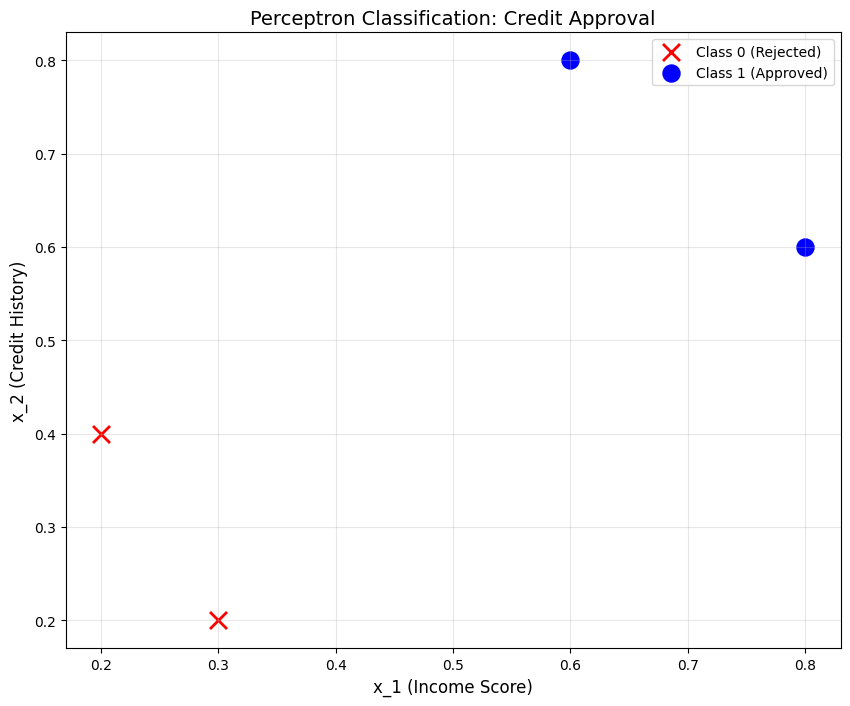

In [10]:
plt.figure(figsize=(10, 8))
    
class_0 = X_train[y_train == 0]
plt.scatter(class_0[:, 0], class_0[:, 1],c='red', marker='x', s=150, linewidths=2, label='Class 0 (Rejected)')
    
class_1 = X_train[y_train == 1]
plt.scatter(class_1[:, 0], class_1[:, 1], c='blue', marker='o', s=150, label='Class 1 (Approved)')
    
plt.xlabel('x_1 (Income Score)', fontsize=12)
plt.ylabel('x_2 (Credit History)', fontsize=12)
plt.title('Perceptron Classification: Credit Approval', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

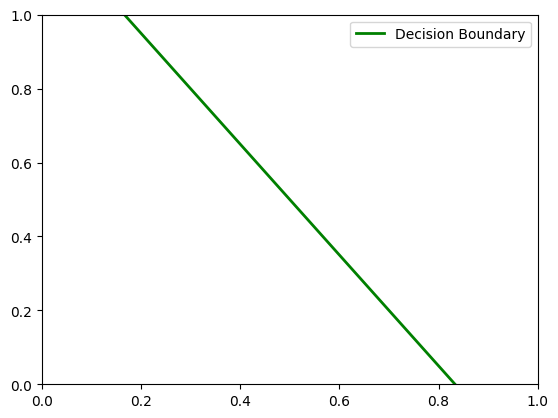


Decision Boundary Equation:
  1.2000*x_1 + 0.8000*x_2 + -1.0000 = 0


In [11]:
w1, w2 = perceptron.coef_[0]
b = perceptron.intercept_[0]
    
x1_range = np.linspace(0, 1, 100)
x2_boundary = -(w1/w2) * x1_range - (b/w2)
    
plt.plot(x1_range, x2_boundary, 'g-', linewidth=2, label='Decision Boundary')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.savefig('perceptron_decision_boundary.png', dpi=150)
plt.show()

print(f"\nDecision Boundary Equation:")
print(f"  {w1:.4f}*x_1 + {w2:.4f}*x_2 + {b:.4f} = 0")


In [12]:

X_new = np.array([
        [0.7, 0.5],
        [0.4, 0.3],
        [0.5, 0.7]
    ])
    
predictions = perceptron.predict(X_new)
    
print("New Instance Predictions:")
for i, (x, pred) in enumerate(zip(X_new, predictions)):
    decision = "Approved" if pred == 1 else "Rejected"
    print(f"  Instance {i+1}: x_1={x[0]}, x_2={x[1]} -> {decision}")


New Instance Predictions:
  Instance 1: x_1=0.7, x_2=0.5 -> Approved
  Instance 2: x_1=0.4, x_2=0.3 -> Rejected
  Instance 3: x_1=0.5, x_2=0.7 -> Approved


# Variant 7

In [14]:
w = np.array([0.2, 0.8, -0.3])
b = -0.4
x = np.array([0.6, 0.5, 0.7])
d = 0
eta = 0.5

z = np.dot(w, x) + b

y = 1 if z >= 0 else 0

error = d - y

w_new = w + eta * error * x
b_new = b + eta * error

print("Weighted sum (z):", round(z, 4))
print("Output (y):", y)
print("Error (d - y):", error)
print("Updated weights:", w_new)
print("Updated bias:", b_new)

Weighted sum (z): -0.09
Output (y): 0
Error (d - y): 0
Updated weights: [ 0.2  0.8 -0.3]
Updated bias: -0.4


In [20]:
X_train = np.array([
    [0.7, 0.6],
    [0.2, 0.3],
    [0.8, 0.5],
    [0.1, 0.4],
    [0.6, 0.8],
    [0.3, 0.1]
])

y_train = np.array([1, 0, 1, 0, 1, 0])

model = Perceptron(
    eta0=1.0,
    max_iter=50,
    random_state=42,
    fit_intercept=True
)

model.fit(X_train, y_train)

w_final = model.coef_[0]
b_final = model.intercept_[0]

print("Final weights:", w_final)
print("Final bias:", b_final)

print("\nDecision boundary equation:")
print(f"{w_final[0]:.2f}x1 + {w_final[1]:.2f}x2 + {b_final:.2f} = 0")

new_customer = np.array([[0.4, 0.7]])
prediction = model.predict(new_customer)

print("\nPrediction for (0.4, 0.7):", prediction[0])


Final weights: [1.6 0.4]
Final bias: -1.0

Decision boundary equation:
1.60x1 + 0.40x2 + -1.00 = 0

Prediction for (0.4, 0.7): 0


In [ ]:
customers = 50000
response_rate = 0.12
mail_cost = 2
profit_per_responder = 35

expected_responders = customers * response_rate
revenue = expected_responders * profit_per_responder
cost = customers * mail_cost
profit = revenue - cost

print("Expected responders:", int(expected_responders))
print("Total revenue: $", revenue)
print("Total cost: $", cost)
print("Expected campaign profit: $", profit)

Expected responders: 6000
Total revenue: $ 210000.0
Total cost: $ 100000
Expected campaign profit: $ 110000.0
ROI (%): 110.0
